In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Rounak\Downloads\Crop_recommendation.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (2200, 8)
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [3]:
# 2 Dataset Overview
print("\nDataset Statistics")
print(df.describe())

print("\nCrop Distribution")
print(df["label"].value_counts())


Dataset Statistics
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  

Crop D

In [4]:
# Encode Target
le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])

In [5]:
# Features and Target
X = df.drop("label", axis=1)
y = df["label"]

In [6]:
#  Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.1, max_depth=3)
model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=300)

In [8]:
# Prediction & Accuracy 
pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.9818181818181818


In [9]:
# Classification Report
print("Classification Report")

print(classification_report(y_test, pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        14
           8       0.85      0.96      0.90        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      0.95      0.98        21
          12       1.00      1.00      1.00        19
          13       0.96      0.96      0.96        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
     

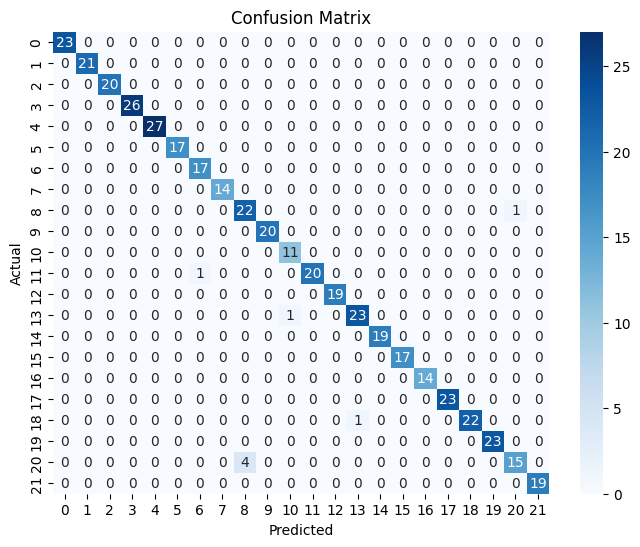

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# Cross Validation
scores = cross_val_score(model, X_scaled, y, cv=5)
print("\nCross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())


Cross Validation Scores: [0.99090909 0.98863636 0.99545455 0.99545455 0.98181818]
Mean CV Accuracy: 0.9904545454545455


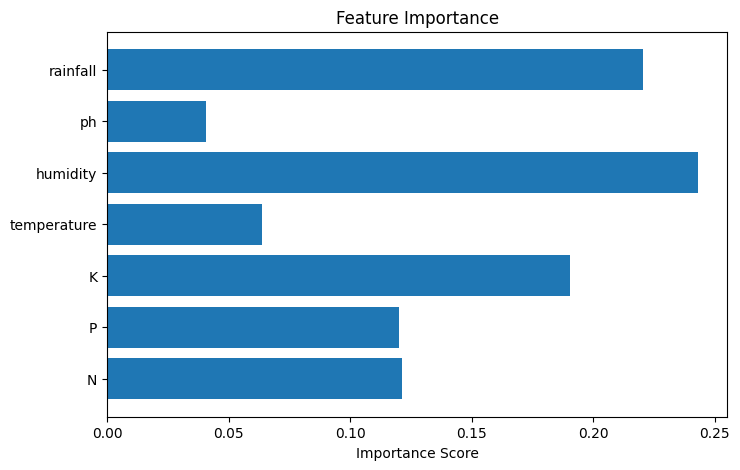

In [12]:
# Feature Importance
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

In [13]:
# Saving the Model
joblib.dump(model, "crop_recommendation_model.pkl")

['crop_recommendation_model.pkl']

In [14]:
# Prediction Function

def recommend_crop(sample):

    sample = scaler.transform([sample])

    prediction = model.predict(sample)

    return le.inverse_transform(prediction)[0]